Counted: Overall 99 found!


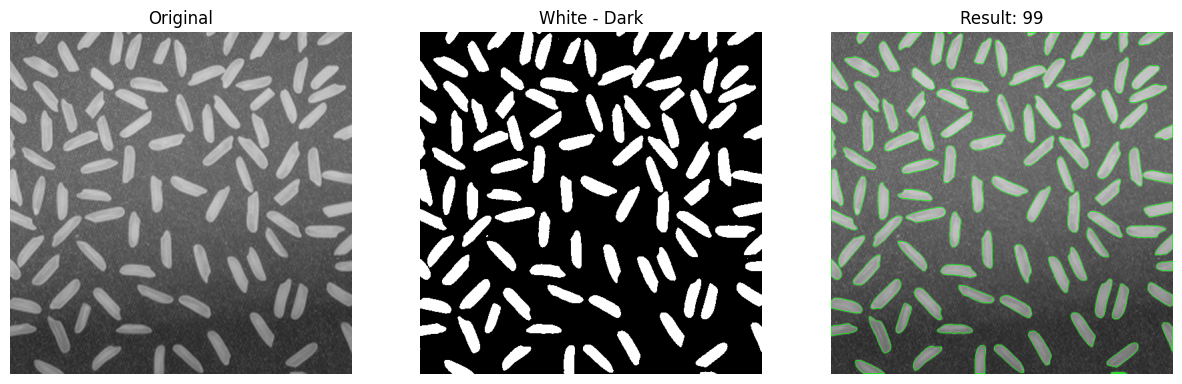

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image_path = '/content/drive/MyDrive/DIP/rice.png'
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


kernel_bg = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
background = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel_bg)

subtracted = cv2.subtract(gray, background)

_, thresh = cv2.threshold(subtracted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel_clean = np.ones((3, 3), np.uint8)
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean, iterations=1)

contours, hierarchy = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output_image = image.copy()
rice_count = 0

min_area = 5

for contour in contours:
    area = cv2.contourArea(contour)
    if area > min_area:
        rice_count += 1
        cv2.drawContours(output_image, [contour], -1, (0, 255, 0), 1)

print(f"Counted: Overall {rice_count} found!")

plt.figure(figsize=(15, 5)) # Result

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title('White - Dark')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f'Result: {rice_count}')
plt.axis('off')

plt.show()